
# Seminární práce 2.
## Počítačové zpracování signálů(KI/PZS)

Autor: Rafael Gumerov (F24635)


# Klasifikace zvukových záznamů na dobré a patologické

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal
from scipy.fft import fft, ifft

1. Nastavil jsem původní soubor.

In [7]:
base_folder = './voice-icar-federico-ii-database-1.0.0'

## 1. Iterace přes všechny záznamy 
- Funkce prochází identifikátory voice001 až voice208 a hledá příslušné soubory.

- Načtení diagnózy – z informačního souboru (-info.txt) extrahuje text diagnózy.

- Klasifikace záznamu – na základě přítomnosti slova "healthy" v diagnóze přiřazuje štítek "Healthy" nebo "Pathological".

- Získání vzorkovací frekvence – z hlavičkového souboru (.hea) načítá vzorkovací frekvenci, jinak použije výchozí hodnotu 8000 Hz.

- Načtení signálu – z textového souboru (.txt) importuje samotný hlasový signál.

- Sestavení datasetu – ukládá všechny informace (ID, signál, frekvenci, diagnózu, štítek) do DataFrame a vrací jej.

In [ ]:
def load_dataset(data_dir):
    data = []
    
    for i in range(1, 209):
        file_id = f"voice{i:03d}"
        info_file = os.path.join(data_dir, f"{file_id}-info.txt")
        signal_file = os.path.join(data_dir, f"{file_id}.txt")
        header_file = os.path.join(data_dir, f"{file_id}.hea")
        
        if not os.path.exists(info_file) or not os.path.exists(signal_file):
            continue
            
        # parse Diagnosis from Info File
        diagnosis = "Unknown"
        with open(info_file, 'r') as f:
            for line in f:
                if line.strip().lower().startswith("diagnosis:"):
                    diagnosis = line.split(":", 1)[1].strip().lower()
                    break
        
        # label logic
        label = "Healthy" if "healthy" in diagnosis else "Pathological"
    
        fs = 8000 
        try:
            with open(header_file, 'r') as f:
                first_line = f.readline().split()
                if len(first_line) >= 3:
                    fs = int(first_line[2])
        except:
            pass

        # load Signal (ASCII format in .txt)
        try:
            signal = np.loadtxt(signal_file)
        except:
            continue
            
        data.append({
            'id': file_id,
            'signal': signal,
            'fs': fs,
            'diagnosis': diagnosis,
            'label': label
        })
        
    return pd.DataFrame(data)

In [ ]:
df_voice = load_dataset(base_folder) 
print(f"Loaded {len(df_voice)} recordings.")
print(df_voice['label'].value_counts())

Loaded 208 recordings.
label
Pathological    151
Healthy          57
Name: count, dtype: int64


## 2. Feature Extraction

Předzpracování signálu

1. **Odstranění ticha** – Ořízne začátek a konec nahrávky, kde je amplituda nižší než 1 % maxima.

2. **Oknování** – Vybere střední úsek (maximálně 1 sekundu dlouhý) a aplikuje na něj Hammingovo okno, což je standardní postup pro spektrální analýzu, aby se zamezilo zkreslení na okrajích úseku.

Výpočet HNR (Harmonics-to-Noise Ratio)

- Počítá poměr energie harmonických složek (periodický hlas) vůči šumu.
- Využívá autokorelaci, kde hledá nejsilnější shodu signálu se sebou samým v rozsahu frekvencí lidského hlasu (60–400 Hz).
- Výsledkem je hodnota v decibelech (dB) – čím vyšší, tím je hlas "čistší" a méně chraptivý.

Výpočet CPP (Cepstral Peak Prominence)

- Provádí cepstrální analýzu (inverzní Fourierova transformace logaritmu spektra).
- Hledá tzv. cepstrální vrchol (odpovídající základní frekvenci hlasu f0) a měří, jak moc vyčnívá nad průměrnou hladinou okolí (šumem).
- Toto je robustní metoda pro hodnocení dysfonie (poruch hlasu) – vyšší hodnota znamená lepší periodicitu hlasu.

Hromadné zpracování (Smyčka)

- Kód projde každý řádek vstupní tabulky df_voice.
- Pokud je signál příliš krátký nebo nekvalitní, přiřadí náhradní hodnoty (HNR = -20, CPP = 0).
- Výsledné příznaky připojí k původním datům do nové tabulky df_final.

In [12]:
def extract_features(signal, fs):
    """
    Extracts HNR and CPP features.
    """
    # 1. Preprocessing: Silence Removal
    threshold = 0.01 * np.max(np.abs(signal))
    active_indices = np.where(np.abs(signal) > threshold)[0]
    
    if len(active_indices) < fs * 0.1:
        return None
    
    start, end = active_indices[0], active_indices[-1]
    signal_trimmed = signal[start:end]
    
    # Windowing: Center 1 second
    center_index = len(signal_trimmed) // 2
    window_size = min(len(signal_trimmed), int(fs * 1.0))
    start_win = center_index - window_size // 2
    end_win = center_index + window_size // 2
    
    segment = signal_trimmed[start_win:end_win]
    window_func = np.hamming(len(segment))
    segment_win = segment * window_func

    # 2. Fourier Analysis (Spectrum)
    N = len(segment_win)
    spectrum = np.abs(fft(segment_win))

    # 3. Cepstral Analysis (Real Cepstrum)
    eps = 1e-10
    log_spectrum = np.log(np.abs(fft(segment_win)) + eps)
    cepstrum = np.real(ifft(log_spectrum))
    
    # 4. Calculate Metrics
    
    # A. HNR via Autocorrelation
    acf = np.correlate(segment_win, segment_win, mode='full')
    acf = acf[len(acf)//2:]
    
    min_pitch, max_pitch = 60, 400
    min_lag = int(fs / max_pitch)
    max_lag = int(fs / min_pitch)
    
    hnr = -20
    if max_lag < len(acf):
        pitch_region = acf[min_lag:max_lag]
        if len(pitch_region) > 0:
            rx_t0 = np.max(pitch_region)
            rx_0 = acf[0]
            if rx_0 > rx_t0 and rx_t0 > 0.0001:
                hnr = 10 * np.log10(rx_t0 / (rx_0 - rx_t0 + eps))

    # B. CPP (Cepstral Peak Prominence)
    valid_cepstrum = cepstrum[min_lag:max_lag]
    if len(valid_cepstrum) > 0:
        cepstral_peak = np.max(valid_cepstrum)
        cpp = cepstral_peak - np.mean(cepstrum[min_lag:])
    else:
        cpp = 0
        
    return {'HNR': hnr, 'CPP': cpp}

# Apply to all recordings
features_list = []
for index, row in df_voice.iterrows():
    feats = extract_features(row['signal'], row['fs'])
    if feats:
        features_list.append(feats)
    else:
        features_list.append({'HNR': -20, 'CPP': 0})

df_features = pd.DataFrame(features_list)
df_final = pd.concat([df_voice, df_features], axis=1)

print("Feature extraction complete.")

Feature extraction complete.


## 3. Classification Algorithm (Rule-Based)

Stanovení dynamických prahů (Trénink)

- Algoritmus se "učí" pouze ze skupiny zdravých vzorků.
- Pro oba parametry (HNR i CPP) vypočítá limitní hodnotu pomocí vzorce: $\text{Průměr} - 1 \times \text{Směrodatná odchylka}$.
- Tím se definuje spodní hranice "normality" – cokoliv, co klesne výrazně pod průměr zdravého hlasu, bude považováno za podezřelé.

Klasifikační logika (Přísné pravidlo)

- Funkce `classify_voice` hodnotí každý neznámý vzorek.
- Uplatňuje přísné kritérium pro zdraví: Aby byl hlas klasifikován jako "Healthy", musí překročit prahové hodnoty pro HNR i CPP současně (skóre 2 ze 2).
- Pokud je byť jen jeden z parametrů pod prahem (signalizuje šum nebo nepravidelnost), je vzorek okamžitě označen jako "Pathological".

Vyhodnocení modelu

- Predikce se aplikují na celý datový soubor.
- Kód porovná vypočítané štítky (`Predicted_Label`) se skutečnou diagnózou (`label`) a vypíše celkovou přesnost (accuracy) modelu v procentech.

In [13]:

healthy_data = df_final[df_final['label'] == 'Healthy']


hnr_threshold = healthy_data['HNR'].mean() - 1.0 * healthy_data['HNR'].std()
cpp_threshold = healthy_data['CPP'].mean() - 1.0 * healthy_data['CPP'].std()

print(f"Thresholds determined: HNR > {hnr_threshold:.2f}, CPP > {cpp_threshold:.2f}")

def classify_voice(row):

    score = 0
    if row['HNR'] > hnr_threshold: score += 1
    if row['CPP'] > cpp_threshold: score += 1
    
    if score == 2:
        return "Healthy"
    else:
        return "Pathological"

df_final['Predicted_Label'] = df_final.apply(classify_voice, axis=1)


correct = (df_final['label'] == df_final['Predicted_Label']).sum()
accuracy = correct / len(df_final)
print(f"Overall Accuracy: {accuracy*100:.2f}%")

Thresholds determined: HNR > 8.64, CPP > 0.24
Overall Accuracy: 54.81%


## Závěr

Naměřená celková přesnost 54,81 % je z hlediska strojového učení velmi nízká. V kontextu binární klasifikace (kde náhodný tip 50/50 dává 50 %) tento výsledek naznačuje, že váš model v současné podobě téměř nefunguje.


## 4. Grafické výstupy

1. Grafy signálů (čas, frekvence, cepstrum)

2. Vizualizace klasifikačního prostoru


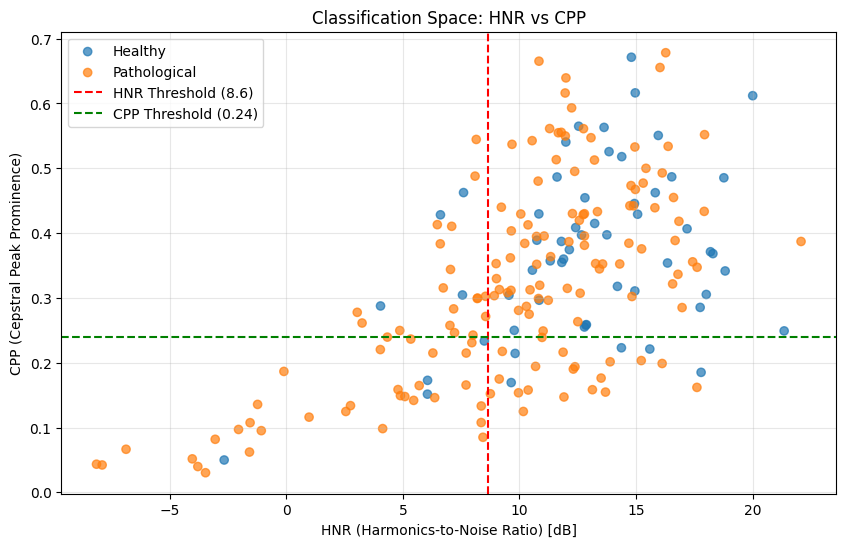

In [15]:
plt.figure(figsize=(10, 6))

groups = df_final.groupby('label')
for name, group in groups:
    plt.scatter(group['HNR'], group['CPP'], marker='o', linestyle='', label=name, alpha=0.7)


plt.axvline(x=hnr_threshold, color='r', linestyle='--', label=f'HNR Threshold ({hnr_threshold:.1f})')
plt.axhline(y=cpp_threshold, color='g', linestyle='--', label=f'CPP Threshold ({cpp_threshold:.2f})')

plt.title("Classification Space: HNR vs CPP")
plt.xlabel("HNR (Harmonics-to-Noise Ratio) [dB]")
plt.ylabel("CPP (Cepstral Peak Prominence)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Grafické rozložení příznaků HNR a CPP potvrzuje značný překryv mezi oběma skupinami, což naznačuje, že tyto parametry samy o sobě k úplné separaci v lineárním prostoru nestačí. Výsledná přesnost modelu tak přímo odráží tuto komplexní strukturu dat, kde nelze vést jednoznačnou dělící linii bez akceptování určité míry chybovosti